# Forest Cover Type Classification

## Goal

This notebook builds a supervised multiclass model that predicts forest cover type from cartographic and terrain features.

The seven target classes represent different dominant tree cover types.

## Main techniques

- multiclass classification
- class imbalance analysis
- logistic regression
- histogram gradient boosting
- Extra Trees
- macro F1-score evaluation
- confusion-pair analysis
- permutation feature importance

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
covtype = fetch_covtype(as_frame=True)

df = covtype.frame.copy()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


In [3]:
target_col = "Cover_Type"

print("Features:", df.shape[1] - 1)
print("Classes:", df[target_col].nunique())
print()

df.info()

Features: 54
Classes: 7

<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_A

## Data loading 

The full Forest Cover Type dataset contains 581,012 observations, 54 predictor features, and one target column.

All 54 predictors are numerical. They include:

- elevation, aspect, and slope
- hydrology distance measurements
- distance to roadways and fire points
- hillshade measurements
- four wilderness-area indicators
- forty soil-type indicators

The target contains seven forest cover classes.

The dataset contained no missing values, although median imputation was retained in the modelling pipelines to keep the preprocessing robust.

In [4]:
MAX_ROWS = 120_000

if len(df) > MAX_ROWS:
    sampled_df, _ = train_test_split(
        df,
        train_size=MAX_ROWS,
        stratify=df[target_col],
        random_state=RANDOM_STATE
    )
else:
    sampled_df = df.copy()

sampled_df = sampled_df.reset_index(drop=True)

print("Rows used:", len(sampled_df))

Rows used: 120000


In [5]:
class_counts = sampled_df[target_col].value_counts().sort_index()
class_rates = sampled_df[target_col].value_counts(
    normalize=True
).sort_index()

class_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_rates * 100
})

class_summary

,count,percentage
Cover_Type,,
1,43753,36.460833
2,58512,48.760000
3,7384,6.153333
4,567,0.472500
5,1961,1.634167
6,3587,2.989167
7,4236,3.530000


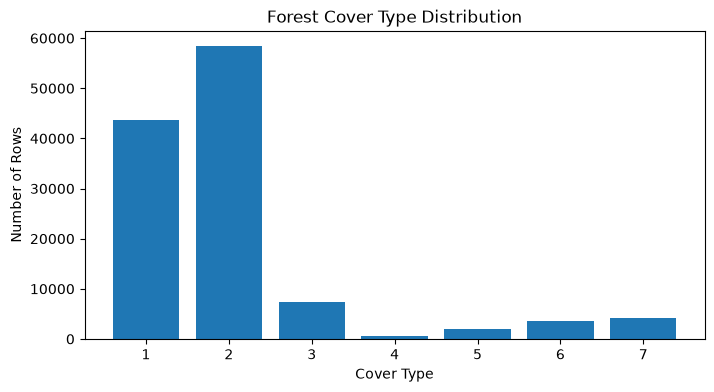

In [6]:
plt.figure(figsize=(8, 4))
plt.bar(
    class_summary.index.astype(str),
    class_summary["count"]
)
plt.title("Forest Cover Type Distribution")
plt.xlabel("Cover Type")
plt.ylabel("Number of Rows")
plt.show()

## Class distribution 

The forest cover classes were strongly imbalanced.

The sampled class distribution was:

| Cover type | Count | Percentage |
|---|---:|---:|
| 1 | 43,753 | 36.46% |
| 2 | 58,512 | 48.76% |
| 3 | 7,384 | 6.15% |
| 4 | 567 | 0.47% |
| 5 | 1,961 | 1.63% |
| 6 | 3,587 | 2.99% |
| 7 | 4,236 | 3.53% |

Cover Type 2 was the largest class and represented almost half of the sample.

Cover Type 4 was extremely rare, with fewer than 600 observations.

Because of this imbalance, accuracy alone could be dominated by Cover Types 1 and 2. Macro F1-score was therefore used for model selection because it gives equal importance to all seven classes.

In [7]:
terrain_features = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Horizontal_Distance_To_Fire_Points"
]

sampled_df[terrain_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Elevation,120000.0,2959.911350,279.662308,1872.0,2810.0,2996.0,3164.0,3856.0
Aspect,120000.0,155.741742,111.886317,0.0,58.0,127.0,261.0,360.0
Slope,120000.0,14.114942,7.496509,0.0,9.0,13.0,18.0,62.0
Horizontal_Distance_To_Hydrology,120000.0,269.517383,212.483965,0.0,108.0,218.0,390.0,1397.0
Vertical_Distance_To_Hydrology,120000.0,46.634500,58.516986,-166.0,7.0,30.0,69.0,598.0
Horizontal_Distance_To_Roadways,120000.0,2345.654892,1555.891468,0.0,1106.0,1995.0,3319.0,7063.0
Horizontal_Distance_To_Fire_Points,120000.0,1976.519300,1319.503672,0.0,1024.0,1708.0,2549.0,7172.0


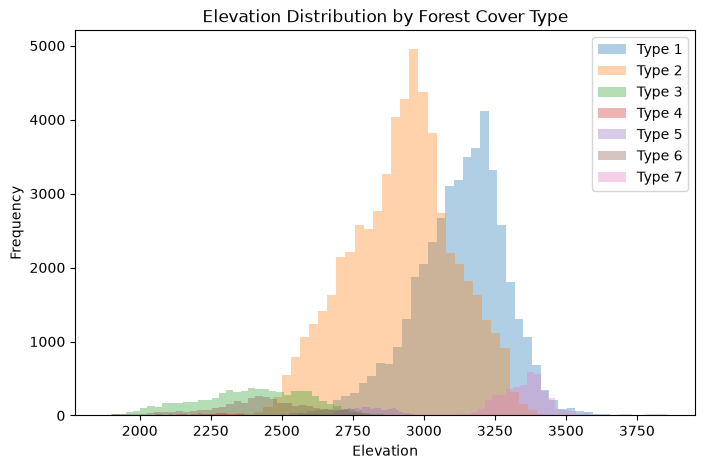

In [8]:
plt.figure(figsize=(8, 5))

for cover_type in sorted(sampled_df[target_col].unique()):
    values = sampled_df.loc[
        sampled_df[target_col] == cover_type,
        "Elevation"
    ]

    plt.hist(
        values,
        bins=40,
        alpha=0.35,
        label=f"Type {cover_type}"
    )

plt.title("Elevation Distribution by Forest Cover Type")
plt.xlabel("Elevation")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Terrain exploration 

Elevation differed substantially across forest cover types.

Cover Type 3 was concentrated at lower elevations, while Cover Type 7 appeared mainly at the highest elevations. Cover Types 1 and 2 occupied overlapping middle-to-high elevation ranges, which helps explain why these two classes were frequently confused by the final model.

The overall elevation values ranged from 1,872 to 3,856, with a median of 2,996.

Although elevation provides strong separation for some classes, considerable overlap remains. Forest cover type therefore cannot be predicted reliably from elevation alone.

In [9]:
X = sampled_df.drop(columns=target_col)
y = sampled_df[target_col]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (72000, 54)
Validation: (24000, 54)
Test: (24000, 54)


## Data split 

A stratified train, validation, and test split was used.

The resulting datasets were:

- Training set: 72,000 rows
- Validation set: 24,000 rows
- Test set: 24,000 rows

Each split contained all seven forest cover types with approximately the same class proportions as the full sample.

The validation set was used for model selection, while the test set remained separate until the final model had been chosen.

In [11]:
class_order = sorted(y.unique())


def evaluate_model(model, X_data, y_true, model_name):
    y_pred = model.predict(X_data)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    for metric, value in result.items():
        if metric != "model":
            print(f"{metric}: {value:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=class_order,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_order
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_order
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    display.plot(ax=ax)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

    return result, y_pred

Dummy Baseline
accuracy: 0.4876
balanced_accuracy: 0.1429
macro_f1: 0.0936
weighted_f1: 0.3196

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      8751
           2       0.49      1.00      0.66     11702
           3       0.00      0.00      0.00      1477
           4       0.00      0.00      0.00       114
           5       0.00      0.00      0.00       392
           6       0.00      0.00      0.00       717
           7       0.00      0.00      0.00       847

    accuracy                           0.49     24000
   macro avg       0.07      0.14      0.09     24000
weighted avg       0.24      0.49      0.32     24000



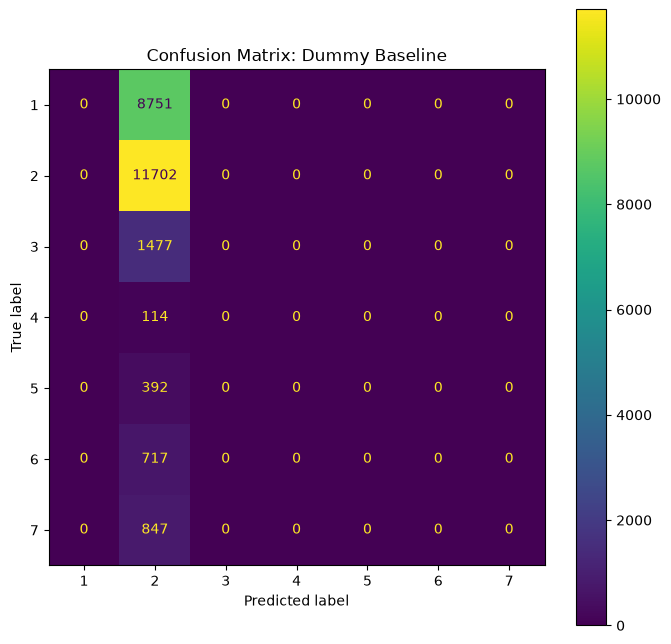

In [12]:
baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

baseline_result, _ = evaluate_model(
    baseline_model,
    X_val,
    y_val,
    "Dummy Baseline"
)

Logistic Regression
accuracy: 0.5992
balanced_accuracy: 0.7063
macro_f1: 0.5061
weighted_f1: 0.6281

Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.66      0.67      8751
           2       0.79      0.52      0.63     11702
           3       0.68      0.57      0.62      1477
           4       0.31      0.90      0.46       114
           5       0.11      0.77      0.18       392
           6       0.32      0.63      0.42       717
           7       0.40      0.89      0.55       847

    accuracy                           0.60     24000
   macro avg       0.47      0.71      0.51     24000
weighted avg       0.70      0.60      0.63     24000



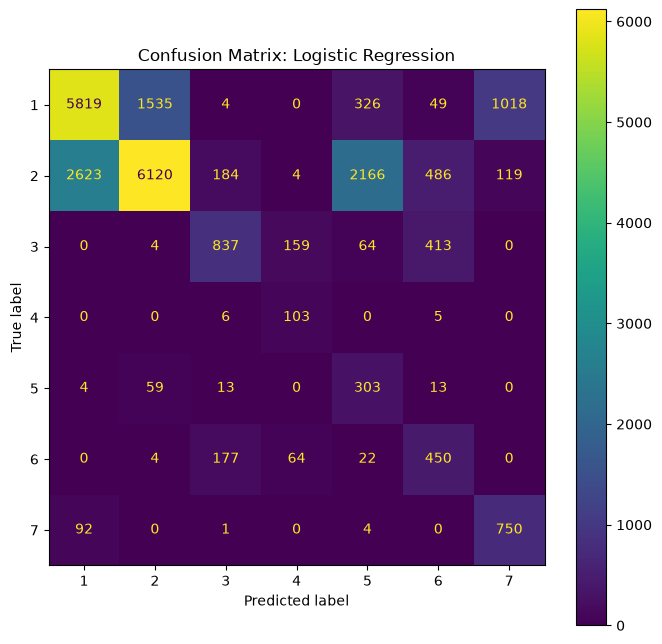

In [13]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

logistic_result, logistic_val_preds = evaluate_model(
    logistic_model,
    X_val,
    y_val,
    "Logistic Regression"
)

Histogram Gradient Boosting
accuracy: 0.8794
balanced_accuracy: 0.8135
macro_f1: 0.8423
weighted_f1: 0.8787

Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.85      0.87      8751
           2       0.87      0.91      0.89     11702
           3       0.88      0.92      0.90      1477
           4       0.86      0.76      0.81       114
           5       0.86      0.60      0.71       392
           6       0.84      0.76      0.80       717
           7       0.96      0.88      0.92       847

    accuracy                           0.88     24000
   macro avg       0.88      0.81      0.84     24000
weighted avg       0.88      0.88      0.88     24000



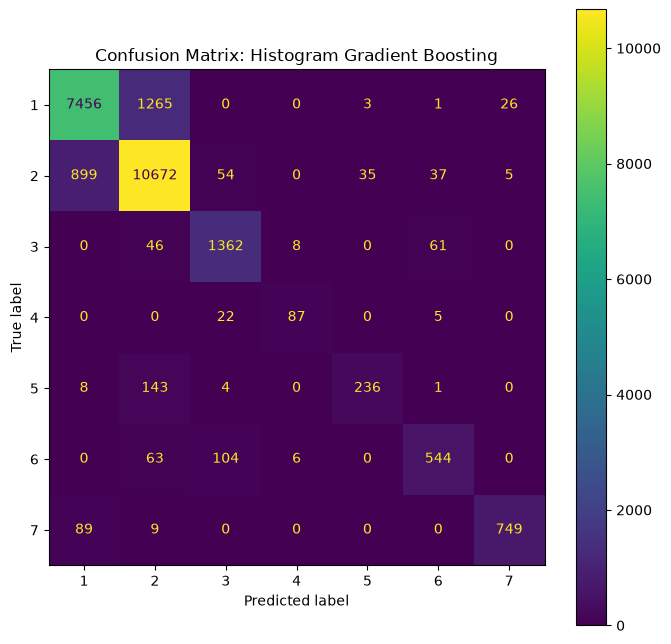

In [14]:
hist_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ))
])

hist_model.fit(X_train, y_train)

hist_result, hist_val_preds = evaluate_model(
    hist_model,
    X_val,
    y_val,
    "Histogram Gradient Boosting"
)

Extra Trees
accuracy: 0.8542
balanced_accuracy: 0.8601
macro_f1: 0.7801
weighted_f1: 0.8564

Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.84      0.86      8751
           2       0.89      0.86      0.88     11702
           3       0.81      0.87      0.84      1477
           4       0.59      0.89      0.71       114
           5       0.52      0.80      0.63       392
           6       0.62      0.82      0.71       717
           7       0.76      0.95      0.84       847

    accuracy                           0.85     24000
   macro avg       0.72      0.86      0.78     24000
weighted avg       0.86      0.85      0.86     24000



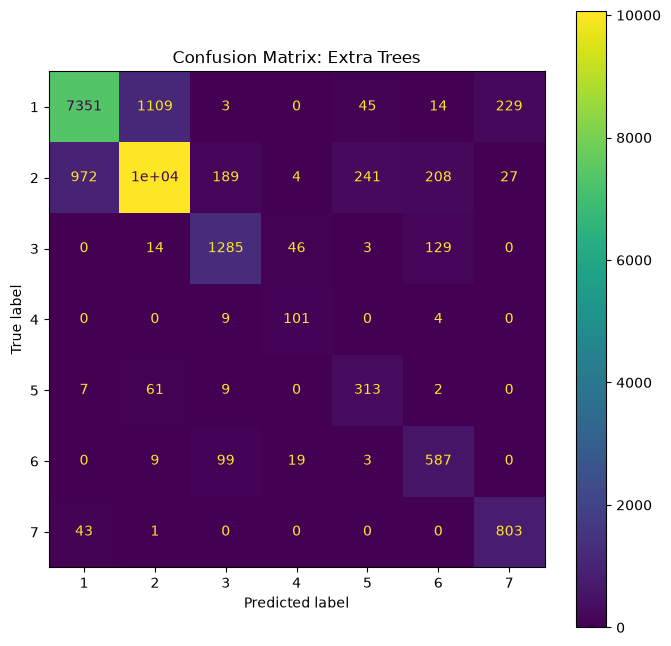

In [15]:
extra_trees_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

extra_trees_model.fit(X_train, y_train)

extra_result, extra_val_preds = evaluate_model(
    extra_trees_model,
    X_val,
    y_val,
    "Extra Trees"
)

In [16]:
results_df = pd.DataFrame([
    baseline_result,
    logistic_result,
    hist_result,
    extra_result
])

results_df.sort_values(
    "macro_f1",
    ascending=False
)

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
2,Histogram Gradient Boosting,0.879417,0.813479,0.842312,0.878668
3,Extra Trees,0.854208,0.860138,0.780070,0.856412
1,Logistic Regression,0.599250,0.706313,0.506143,0.628058
0,Dummy Baseline,0.487583,0.142857,0.093648,0.319629


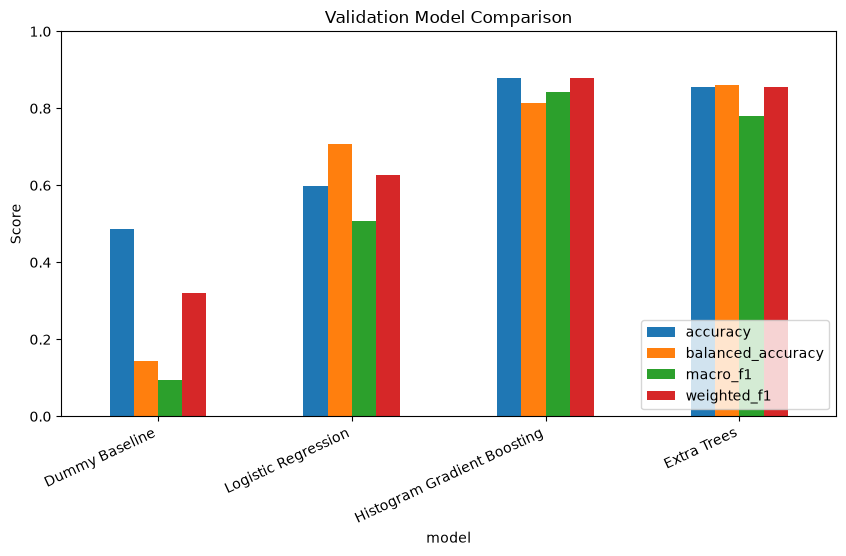

In [17]:
plot_df = results_df.set_index("model")[
    [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "weighted_f1"
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Validation Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower right")
plt.show()

## Baseline model 

The dummy baseline predicted every observation as Cover Type 2, the most common class.

It achieved:

- Accuracy: 0.4876
- Balanced accuracy: 0.1429
- Macro F1-score: 0.0936
- Weighted F1-score: 0.3196

Although the baseline achieved almost 49% accuracy, it completely failed to identify six of the seven forest classes.

This demonstrates why accuracy is misleading for this imbalanced multiclass problem.

## Logistic regression note

Logistic regression achieved:

- Accuracy: 0.5992
- Balanced accuracy: 0.7063
- Macro F1-score: 0.5061
- Weighted F1-score: 0.6281

Class weighting allowed the model to detect minority classes more often than the baseline. For example, it achieved recall of 0.90 for Cover Type 4 and 0.89 for Cover Type 7.

However, its precision for several minority classes was low:

- Cover Type 4 precision: 0.31
- Cover Type 5 precision: 0.11
- Cover Type 6 precision: 0.32
- Cover Type 7 precision: 0.40

This means the model overpredicted minority classes in an attempt to balance recall. The linear decision boundaries were also too simple to capture the full relationships between terrain, soil, and wilderness features.

## Histogram gradient boosting note

Histogram Gradient Boosting achieved the strongest validation result:

- Accuracy: 0.8794
- Balanced accuracy: 0.8135
- Macro F1-score: 0.8423
- Weighted F1-score: 0.8787

The model performed strongly across both common and uncommon classes.

Its highest class-level F1-scores were:

- Cover Type 7: 0.92
- Cover Type 3: 0.90
- Cover Type 2: 0.89
- Cover Type 1: 0.87

Its weakest class was Cover Type 5, with an F1-score of 0.71 and recall of 0.60.

The strong performance suggests that forest cover classes depend on non-linear interactions between elevation, distances, wilderness regions, and soil characteristics.

## Extra Trees note

Extra Trees achieved:

- Accuracy: 0.8542
- Balanced accuracy: 0.8601
- Macro F1-score: 0.7801
- Weighted F1-score: 0.8564

Extra Trees had the highest balanced accuracy of the tested models and achieved strong recall for minority classes:

- Cover Type 4 recall: 0.89
- Cover Type 5 recall: 0.80
- Cover Type 6 recall: 0.82
- Cover Type 7 recall: 0.95

However, its precision for these minority classes was lower, which reduced macro F1-score.

Compared with Histogram Gradient Boosting, Extra Trees detected more minority-class observations but produced more false-positive predictions for those classes.

In [18]:
model_lookup = {
    "Logistic Regression": logistic_model,
    "Histogram Gradient Boosting": hist_model,
    "Extra Trees": extra_trees_model
}

best_model_name = (
    results_df[
        results_df["model"] != "Dummy Baseline"
    ]
    .sort_values("macro_f1", ascending=False)
    .iloc[0]["model"]
)

best_model = model_lookup[best_model_name]

print("Best model:", best_model_name)

Best model: Histogram Gradient Boosting


Histogram Gradient Boosting, Test Set
accuracy: 0.8788
balanced_accuracy: 0.8159
macro_f1: 0.8396
weighted_f1: 0.8779

Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.85      0.87      8751
           2       0.87      0.91      0.89     11703
           3       0.89      0.91      0.90      1477
           4       0.83      0.83      0.83       113
           5       0.84      0.55      0.66       392
           6       0.84      0.78      0.81       717
           7       0.95      0.88      0.91       847

    accuracy                           0.88     24000
   macro avg       0.87      0.82      0.84     24000
weighted avg       0.88      0.88      0.88     24000



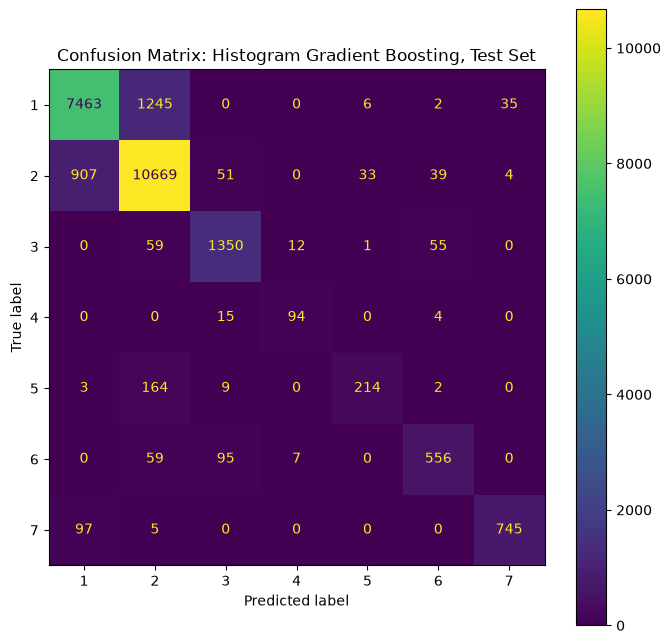

In [19]:
test_result, test_preds = evaluate_model(
    best_model,
    X_test,
    y_test,
    f"{best_model_name}, Test Set"
)

## Final test result note

The selected Histogram Gradient Boosting model achieved:

- Accuracy: 0.8788
- Balanced accuracy: 0.8159
- Macro F1-score: 0.8396
- Weighted F1-score: 0.8779

The test macro F1-score was only 0.0027 lower than the validation macro F1-score:

- Validation macro F1: 0.8423
- Test macro F1: 0.8396

This very small difference indicates that the model generalised consistently to the unseen test data.

The strongest test classes were:

- Cover Type 7: F1-score of 0.91
- Cover Type 3: F1-score of 0.90
- Cover Type 2: F1-score of 0.89

The weakest class was Cover Type 5, with an F1-score of 0.66 and recall of 0.55.

## Model comparison 

The best validation model was Histogram Gradient Boosting.

The validation results were:

| Model | Accuracy | Balanced accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| Histogram Gradient Boosting | 0.8794 | 0.8135 | 0.8423 | 0.8787 |
| Extra Trees | 0.8542 | 0.8601 | 0.7801 | 0.8564 |
| Logistic Regression | 0.5992 | 0.7063 | 0.5061 | 0.6281 |
| Dummy Baseline | 0.4876 | 0.1429 | 0.0936 | 0.3196 |

Histogram Gradient Boosting was selected because it achieved the highest macro F1-score.

Extra Trees produced slightly higher balanced accuracy, but Histogram Gradient Boosting achieved a better balance between precision and recall across the seven forest classes.

In [20]:
cm = confusion_matrix(
    y_test,
    test_preds,
    labels=class_order
)

confusion_rows = []

for actual_index, actual_class in enumerate(class_order):
    for predicted_index, predicted_class in enumerate(class_order):
        if actual_class != predicted_class:
            confusion_rows.append({
                "actual_class": actual_class,
                "predicted_class": predicted_class,
                "count": cm[actual_index, predicted_index]
            })

confusion_df = (
    pd.DataFrame(confusion_rows)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

confusion_df.head(10)

,actual_class,predicted_class,count
0,1,2,1245
1,2,1,907
2,5,2,164
3,7,1,97
4,6,3,95
5,3,2,59
6,6,2,59
7,3,6,55
8,2,3,51
9,2,6,39


## Confusion analysis 

The most common confusion was Cover Type 1 being predicted as Cover Type 2, which occurred 1,245 times.

The reverse confusion was also common:

- Cover Type 2 predicted as Cover Type 1: 907 cases

Other notable errors included:

- Cover Type 5 predicted as Cover Type 2: 164 cases
- Cover Type 7 predicted as Cover Type 1: 97 cases
- Cover Type 6 predicted as Cover Type 3: 95 cases
- Cover Type 3 predicted as Cover Type 2: 59 cases
- Cover Type 6 predicted as Cover Type 2: 59 cases

Cover Types 1 and 2 were the dominant confusion pair. Their elevation distributions overlap considerably, and they may also share similar soil, terrain, wilderness, and distance characteristics.

Cover Type 5 was especially difficult because it was rare and was often absorbed into the much larger Cover Type 2 class.

In [21]:
importance_sample_size = min(5000, len(X_test))

importance_indices = X_test.sample(
    n=importance_sample_size,
    random_state=RANDOM_STATE
).index

X_importance = X_test.loc[importance_indices]
y_importance = y_test.loc[importance_indices]

In [22]:
perm_result = permutation_importance(
    best_model,
    X_importance,
    y_importance,
    n_repeats=3,
    random_state=RANDOM_STATE,
    scoring="f1_macro",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_importance.columns,
    "importance": perm_result.importances_mean,
    "std": perm_result.importances_std
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance,std
0,Elevation,0.603333,0.004755
5,Horizontal_Distance_To_Roadways,0.228870,0.001908
9,Horizontal_Distance_To_Fire_Points,0.206973,0.009916
10,Wilderness_Area_0,0.086593,0.004158
3,Horizontal_Distance_To_Hydrology,0.076697,0.006497
13,Wilderness_Area_3,0.065885,0.006260
6,Hillshade_9am,0.048165,0.006436
4,Vertical_Distance_To_Hydrology,0.045502,0.007188
7,Hillshade_Noon,0.043748,0.002106
16,Soil_Type_2,0.040848,0.001871


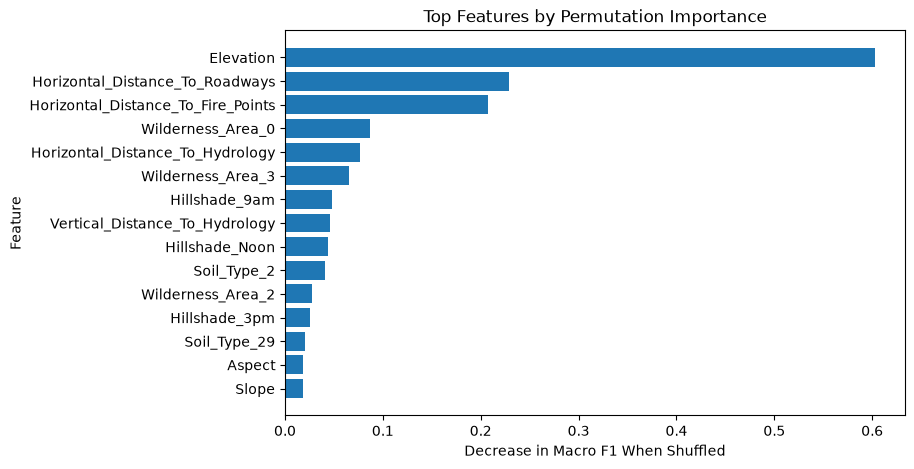

In [23]:
top_features = importance_df.head(15)

plt.figure(figsize=(8, 5))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title("Top Features by Permutation Importance")
plt.xlabel("Decrease in Macro F1 When Shuffled")
plt.ylabel("Feature")
plt.show()

## Feature importance 

Permutation importance was calculated on a sample of 5,000 test observations using macro F1-score.

The strongest predictors were:

1. Elevation
2. Horizontal distance to roadways
3. Horizontal distance to fire points
4. Wilderness Area 0
5. Horizontal distance to hydrology
6. Wilderness Area 3
7. Hillshade at 9am
8. Vertical distance to hydrology
9. Hillshade at noon
10. Soil Type 2

Elevation was by far the most influential feature. Shuffling it reduced macro F1-score by approximately 0.603.

The next strongest features were:

- distance to roadways: importance of approximately 0.229
- distance to fire points: importance of approximately 0.207
- Wilderness Area 0: importance of approximately 0.087
- distance to hydrology: importance of approximately 0.077

These results indicate that forest cover classification depends strongly on elevation, geographic accessibility, proximity to environmental landmarks, wilderness region, sunlight exposure, and soil type.

Permutation importance measures predictive usefulness rather than ecological causation.